# Distribución Temporal
Análisis de las fechas de los registros en `dataset_ozono_predictivo.parquet`

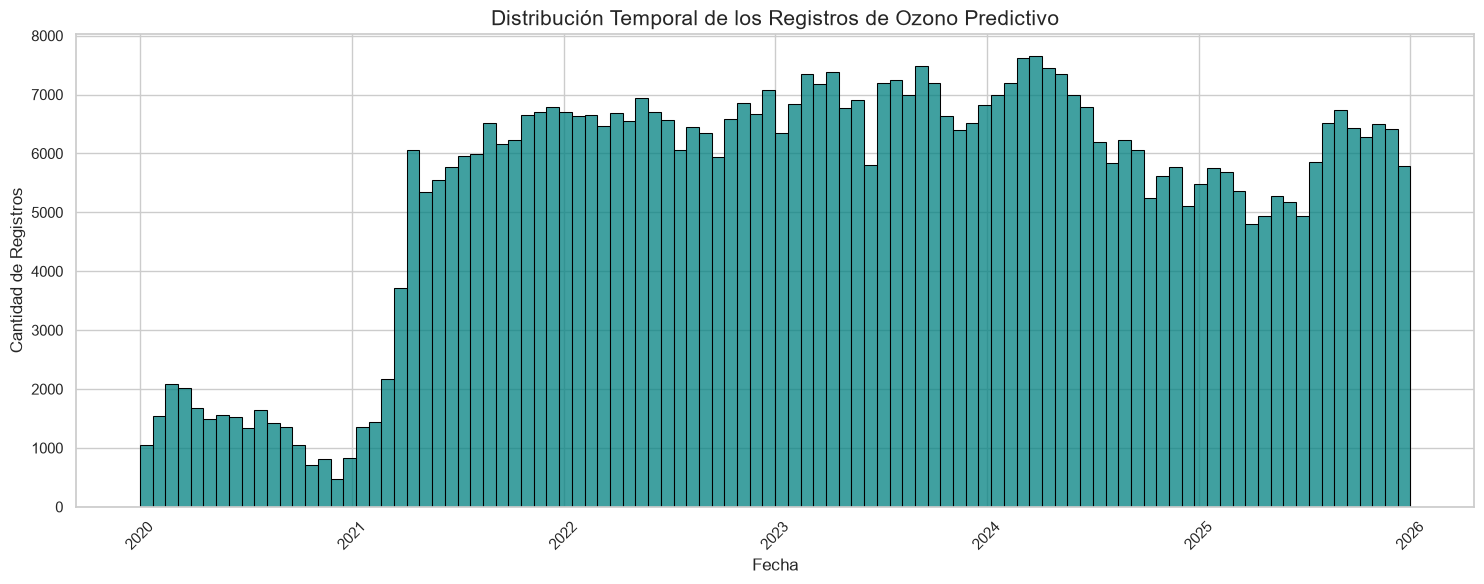

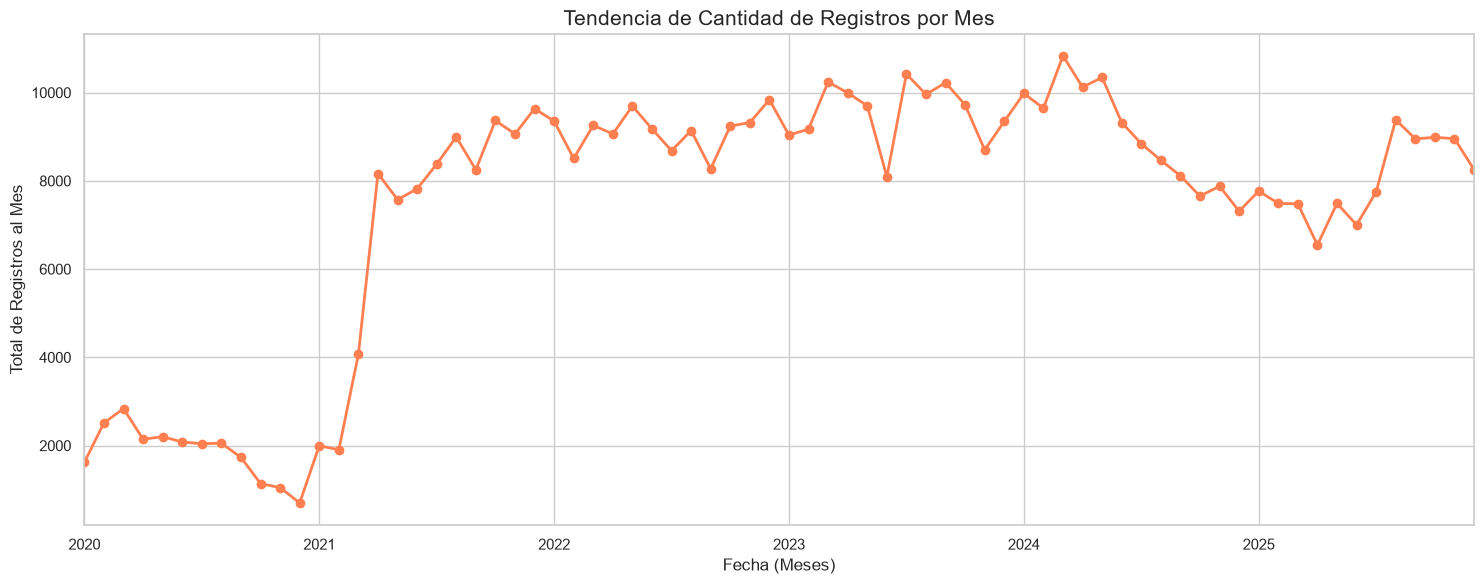

Resumen Temporal:
Fecha mínima: 2020-01-01 05:00:00
Fecha máxima: 2025-12-31 23:00:00
Total de registros: 536,075


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Cargar los datos
file_path = 'data/ml_ready/dataset_ozono_predictivo.parquet'
df = pd.read_parquet(file_path)

# Asegurar que la columna Date es de tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

# Graficar la distribución temporal (Histograma de conteo por fecha)
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid")
sns.histplot(data=df, x='Date', bins=100, color='teal', edgecolor='black')

plt.title('Distribución Temporal de los Registros de Ozono Predictivo', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico alternativo: Conteo de registros por mes para ver estacionalidad
plt.figure(figsize=(15, 6))
df_monthly = df.set_index('Date').resample('ME').size()
df_monthly.plot(kind='line', marker='o', color='coral', linewidth=2)
plt.title('Tendencia de Cantidad de Registros por Mes', fontsize=15)
plt.xlabel('Fecha (Meses)', fontsize=12)
plt.ylabel('Total de Registros al Mes', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar resumen de las fechas
print("Resumen Temporal:")
print(f"Fecha mínima: {df['Date'].min()}")
print(f"Fecha máxima: {df['Date'].max()}")
print(f"Total de registros: {len(df):,}")